In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/raw/bank_reviews_cleaned.csv')
df_sentiment = pd.read_csv('../data/raw/bank_reviews_with_sentiment.csv')

print("Data loaded")
print(df['bank'].value_counts())

Data loaded
bank
BOA       430
Dashen    405
CBE       380
Name: count, dtype: int64


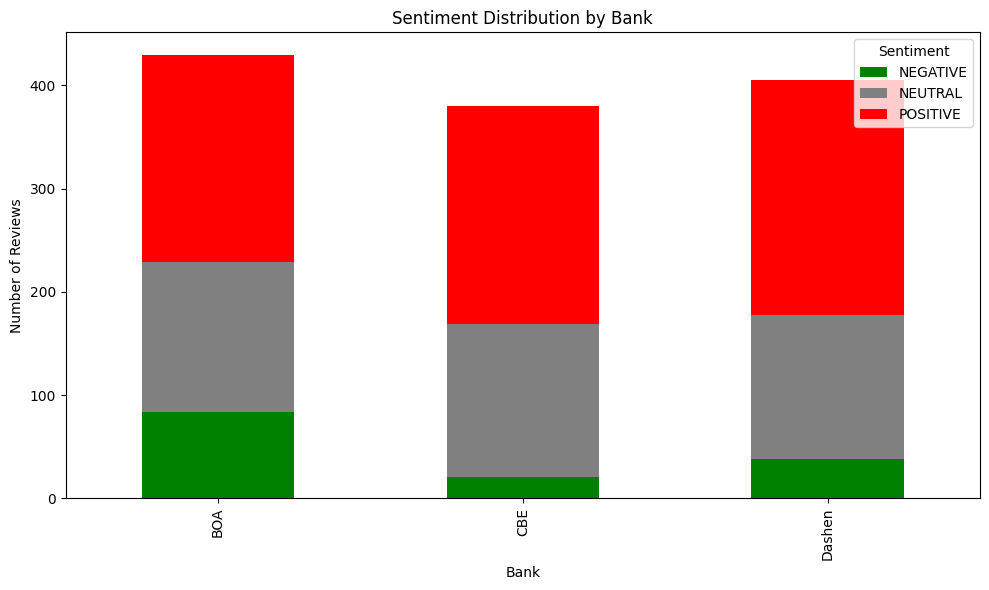

In [2]:
# Merge sentiment with bank data
df_combined = df.merge(df_sentiment[['review_id', 'sentiment_label']], 
                        left_index=True, right_index=True, how='left')

# Count sentiment by bank
sentiment_counts = df_combined.groupby(['bank', 'sentiment_label']).size().unstack()

# Plot
sentiment_counts.plot(kind='bar', stacked=True, figsize=(10, 6), 
                      color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../data/raw/sentiment_by_bank.png')
plt.show()

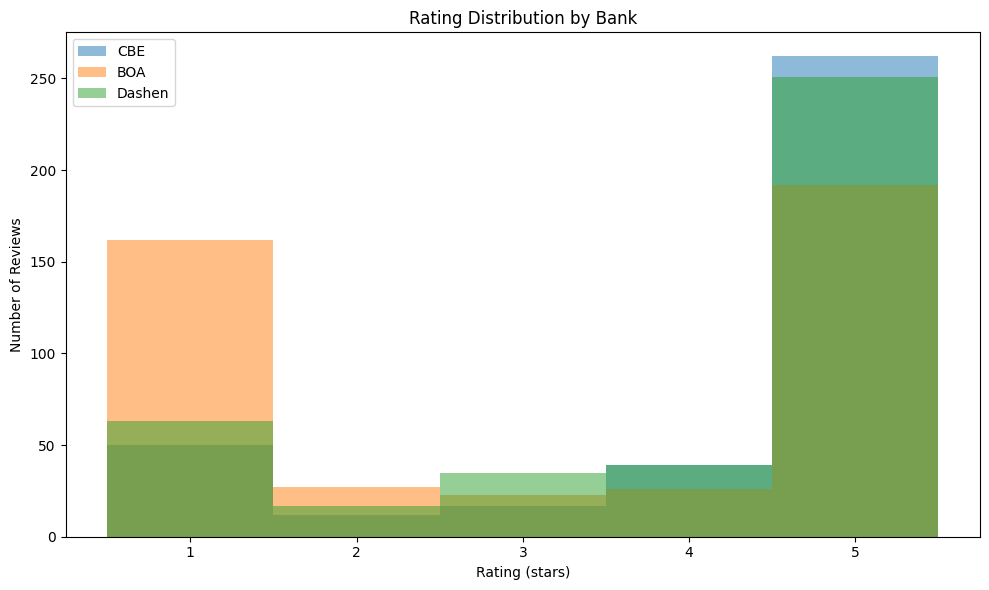

In [3]:
plt.figure(figsize=(10, 6))
for bank in df['bank'].unique():
    subset = df[df['bank'] == bank]
    plt.hist(subset['rating'], alpha=0.5, label=bank, bins=5, range=(0.5, 5.5))
plt.title('Rating Distribution by Bank')
plt.xlabel('Rating (stars)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('../data/raw/rating_distribution.png')
plt.show()

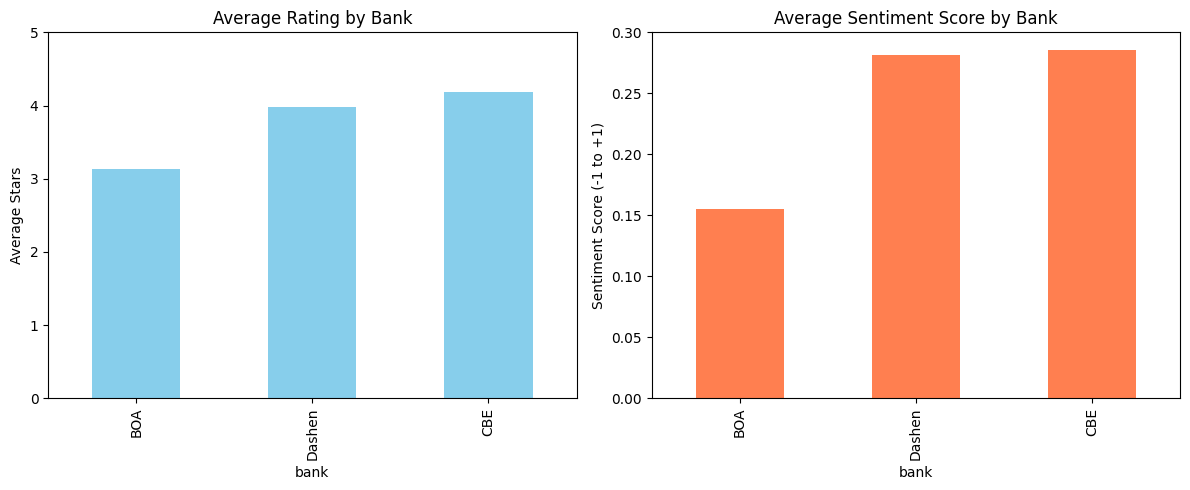

In [4]:
# Average rating per bank
avg_rating = df.groupby('bank')['rating'].mean().sort_values()

# Average sentiment score per bank
avg_sentiment = df_sentiment.groupby('bank')['sentiment_score'].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

avg_rating.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Average Rating by Bank')
ax1.set_ylabel('Average Stars')
ax1.set_ylim(0, 5)

avg_sentiment.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Average Sentiment Score by Bank')
ax2.set_ylabel('Sentiment Score (-1 to +1)')

plt.tight_layout()
plt.savefig('../data/raw/avg_rating_sentiment.png')
plt.show()

## Bank-Specific Recommendations

### CBE (Commercial Bank of Ethiopia)
**Pain Points:** Login issues, slow performance
**Recommendations:**
1. Optimize login flow (reduce steps)
2. Improve app loading speed
3. Add biometric login option

### BOA (Bank of Abyssinia)
**Pain Points:** OTP failures, transaction problems
**Recommendations:**
1. Fix OTP delivery system
2. Add transaction retry mechanism
3. Improve error messages

### Dashen Bank
**Pain Points:** App crashes, but users like fingerprint login
**Recommendations:**
1. Fix stability issues (crashes)
2. Promote fingerprint login feature
3. Add more biometric options